# World Cup 2026 EDA

A companion piece to my [World Cup 2026 Group Stage Tracker](https://github.com/jimmy-ai2/world-cup-tracker) — this time exploring the data behind nearly a century of World Cup history, and what's different about the first-ever 48-team format.

**Sections:**
1. Setup & Imports
2. Load & Inspect
3. Clean
4. Historical Trends
5. Golden Boot Angle
6. The 48-Team Era: 2026 in Context
7. Group Stage Deep Dive
8. Results So Far (placeholder — updated as the tournament progresses)
9. Wrap-up / Key Takeaways


## 1. Setup & Imports

This section brings in the core stack for the whole notebook. `pandas` handles the data itself, `matplotlib`/`seaborn` handle everything visual, and the display settings exist for a specific reason: several columns later on (like `best_wc_result`) hold long text strings that pandas would otherwise truncate — setting `max_colwidth` to `None` means we see the full picture when inspecting data, not a cut-off preview.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings — some columns (e.g. best_wc_result) hold long strings
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

# Plot style — keep it consistent with the tracker's dark navy / cyan look later if desired
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


## 2. Load & Inspect

Before touching or cleaning anything, the first move is just loading all five source files and getting a feel for their shape — row counts, column names, and dtypes. This step exists to catch surprises early: missing values, unexpected data types, or a file that didn't load the way it was expected to. Nothing gets fixed here yet, this is purely reconnaissance.

In [44]:
wc26_fixtures = pd.read_csv("data/wc_2026_fixtures.csv")
wc26_teams = pd.read_csv("data/wc_2026_teams.csv")
wc_editions = pd.read_csv("data/wc_all_editions.csv")
wc_matches = pd.read_csv("data/wc_all_matches.csv")
wc_top_scorers = pd.read_csv("data/wc_top_scorers.csv")

In [45]:
wc26_fixtures.head()

,group,stage,team1,team2,venue,city,country,date,kickoff_et,team1_confederation,team1_fifa_rank,team1_coach,team2_confederation,team2_fifa_rank,team2_coach
0,A,Group Stage,Mexico,South Africa,Estadio Azteca,Mexico City,Mexico,2026-06-11,20:00 ET,CONCACAF,15.0,Javier Aguirre,CAF,60.0,Hugo Broos
1,A,Group Stage,South Korea,Czechia,Estadio Akron,Guadalajara,Mexico,2026-06-11,22:00 ET,AFC,25.0,Hong Myung-bo,UEFA,41.0,Ivan Hasek
2,A,Group Stage,South Korea,Mexico,Estadio Akron,Guadalajara,Mexico,2026-06-18,21:00 ET,AFC,25.0,Hong Myung-bo,CONCACAF,15.0,Javier Aguirre
3,A,Group Stage,Czechia,South Africa,Estadio Akron,Guadalajara,Mexico,2026-06-18,18:00 ET,UEFA,41.0,Ivan Hasek,CAF,60.0,Hugo Broos
4,A,Group Stage,Czechia,Mexico,Estadio Azteca,Mexico City,Mexico,2026-06-24,21:00 ET,UEFA,41.0,Ivan Hasek,CONCACAF,15.0,Javier Aguirre


In [46]:
wc26_fixtures.shape

(104, 15)

In [47]:
wc26_fixtures.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   group                72 non-null     str    
 1   stage                104 non-null    str    
 2   team1                104 non-null    str    
 3   team2                104 non-null    str    
 4   venue                104 non-null    str    
 5   city                 104 non-null    str    
 6   country              104 non-null    str    
 7   date                 104 non-null    str    
 8   kickoff_et           104 non-null    str    
 9   team1_confederation  72 non-null     str    
 10  team1_fifa_rank      72 non-null     float64
 11  team1_coach          72 non-null     str    
 12  team2_confederation  72 non-null     str    
 13  team2_fifa_rank      72 non-null     float64
 14  team2_coach          72 non-null     str    
dtypes: float64(2), str(13)
memory usage: 12.3 KB


In [48]:
wc26_teams.head()

,team,group,confederation,fifa_rank,coach,best_wc_result,debut_2026
0,Mexico,A,CONCACAF,15,Javier Aguirre,"Quarter-finals (1970,1986)",No
1,South Africa,A,CAF,60,Hugo Broos,"Group stage (1998,2002,2010)",No
2,South Korea,A,AFC,25,Hong Myung-bo,Semi-finals (2002),No
3,Czechia,A,UEFA,41,Ivan Hasek,"Runner-up (1934,1962)",No
4,Canada,B,CONCACAF,30,Jesse Marsch,"Group stage (1986,2022)",No


In [49]:
wc26_teams.shape

(48, 7)

In [50]:
wc26_teams.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   team            48 non-null     str  
 1   group           48 non-null     str  
 2   confederation   48 non-null     str  
 3   fifa_rank       48 non-null     int64
 4   coach           48 non-null     str  
 5   best_wc_result  48 non-null     str  
 6   debut_2026      48 non-null     str  
dtypes: int64(1), str(6)
memory usage: 2.8 KB


In [51]:
wc_editions.head()

,edition,year,host,champion,runner_up,third_place,fourth_place,teams,matches,goals,goals_per_match,attendance,top_scorer,top_scorer_country,top_scorer_goals,start_date,end_date,final_city,host_won,format
0,1,1930,Uruguay,Uruguay,Argentina,United States,Yugoslavia,13,18,70,3.89,590549,Guillermo Stábile,Argentina,8,July 13,July 30,Montevideo,No,Round Robin
1,2,1934,Italy,Italy,Czechoslovakia,Germany,Austria,16,17,70,4.12,363000,Oldřich Nejedlý,Czechoslovakia,5,May 27,June 10,Rome,Yes,Knockout
2,3,1938,France,Italy,Hungary,Brazil,Sweden,15,18,84,4.67,375700,Leônidas,Brazil,7,June 4,June 19,Paris,Yes,Knockout
3,4,1950,Brazil,Uruguay,Brazil,Sweden,Spain,13,22,88,4.00,1045246,Ademir,Brazil,8,June 24,July 16,Rio de Janeiro,No,Round Robin Final
4,5,1954,Switzerland,West Germany,Hungary,Austria,Uruguay,16,26,140,5.38,768607,Sándor Kocsis,Hungary,11,June 16,July 4,Bern,No,Knockout


In [52]:
wc_editions.shape

(22, 20)

In [53]:
wc_editions.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   edition             22 non-null     int64  
 1   year                22 non-null     int64  
 2   host                22 non-null     str    
 3   champion            22 non-null     str    
 4   runner_up           22 non-null     str    
 5   third_place         22 non-null     str    
 6   fourth_place        22 non-null     str    
 7   teams               22 non-null     int64  
 8   matches             22 non-null     int64  
 9   goals               22 non-null     int64  
 10  goals_per_match     22 non-null     float64
 11  attendance          22 non-null     int64  
 12  top_scorer          22 non-null     str    
 13  top_scorer_country  22 non-null     str    
 14  top_scorer_goals    22 non-null     int64  
 15  start_date          22 non-null     str    
 16  end_date            2

In [54]:
wc_editions.describe()

,edition,year,teams,matches,goals,goals_per_match,attendance,top_scorer_goals
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,2.200000e+01,22.000000
mean,11.500000,1978.909091,22.227273,43.818182,123.636364,3.065909,1.981513e+06,7.090909
std,6.493587,27.738419,7.602830,17.632860,34.841882,0.840055,1.098572e+06,2.158242
min,1.000000,1930.000000,13.000000,17.000000,70.000000,2.210000,3.630000e+05,4.000000
25%,6.250000,1959.000000,16.000000,32.000000,90.500000,2.572500,9.311905e+05,6.000000
50%,11.500000,1980.000000,20.000000,45.000000,129.000000,2.700000,1.816015e+06,6.000000
75%,16.750000,2001.000000,32.000000,64.000000,146.750000,3.442500,2.970101e+06,8.000000
max,22.000000,2022.000000,32.000000,64.000000,172.000000,5.380000,3.587538e+06,13.000000


In [55]:
wc_matches.head()

,year,stage,team1,score1,score2,team2,venue,city,country,date,notes
0,1930,Group Stage,France,4,1,Mexico,Estadio Centenario,Montevideo,Uruguay,1930-07-13,First ever WC match
1,1930,Group Stage,USA,3,0,Belgium,Estadio Centenario,Montevideo,Uruguay,1930-07-13,NaN
2,1930,Group Stage,Yugoslavia,2,1,Brazil,Estadio Centenario,Montevideo,Uruguay,1930-07-14,NaN
3,1930,Group Stage,Uruguay,1,0,Peru,Estadio Centenario,Montevideo,Uruguay,1930-07-18,NaN
4,1930,Group Stage,Argentina,6,3,USA,Estadio Centenario,Montevideo,Uruguay,1930-07-26,NaN


In [56]:
wc_matches.shape

(184, 11)

In [57]:
wc_matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   year     184 non-null    int64
 1   stage    184 non-null    str  
 2   team1    184 non-null    str  
 3   score1   184 non-null    int64
 4   score2   184 non-null    int64
 5   team2    184 non-null    str  
 6   venue    184 non-null    str  
 7   city     184 non-null    str  
 8   country  184 non-null    str  
 9   date     184 non-null    str  
 10  notes    102 non-null    str  
dtypes: int64(3), str(8)
memory usage: 15.9 KB


In [58]:
wc_matches.describe()

,year,score1,score2
count,184.000000,184.000000,184.000000
mean,1984.260870,2.358696,1.152174
std,27.962844,1.746700,1.436714
min,1930.000000,0.000000,0.000000
25%,1962.000000,1.000000,0.000000
50%,1990.000000,2.000000,1.000000
75%,2010.000000,3.000000,2.000000
max,2022.000000,9.000000,10.000000


In [59]:
wc_top_scorers.head()

,edition,year,player,country,position,goals,assists,penalties,matches_played,host,team_result
0,1,1930,Guillermo Stábile,Argentina,FW,8,0,0,4,Uruguay,Champions
1,2,1934,Oldřich Nejedlý,Czechoslovakia,FW,5,0,0,4,Italy,Semi-final
2,3,1938,Leônidas,Brazil,FW,7,0,0,5,France,Third place
3,4,1950,Ademir,Brazil,FW,8,0,0,6,Brazil,Runner-up
4,5,1954,Sándor Kocsis,Hungary,FW,11,0,0,5,Switzerland,Runner-up


In [60]:
wc_top_scorers.shape

(22, 11)

In [61]:
wc_top_scorers.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   edition         22 non-null     int64
 1   year            22 non-null     int64
 2   player          22 non-null     str  
 3   country         22 non-null     str  
 4   position        22 non-null     str  
 5   goals           22 non-null     int64
 6   assists         22 non-null     int64
 7   penalties       22 non-null     int64
 8   matches_played  22 non-null     int64
 9   host            22 non-null     str  
 10  team_result     22 non-null     str  
dtypes: int64(6), str(5)
memory usage: 2.0 KB


In [62]:
wc_top_scorers.describe()

,edition,year,goals,assists,penalties,matches_played
count,22.000000,22.000000,22.000000,22.000000,22.0,22.000000
mean,11.500000,1978.909091,7.090909,0.318182,0.0,5.954545
std,6.493587,27.738419,2.158242,0.838727,0.0,0.950051
min,1.000000,1930.000000,4.000000,0.000000,0.0,4.000000
25%,6.250000,1959.000000,6.000000,0.000000,0.0,5.250000
50%,11.500000,1980.000000,6.000000,0.000000,0.0,6.000000
75%,16.750000,2001.000000,8.000000,0.000000,0.0,7.000000
max,22.000000,2022.000000,13.000000,3.000000,0.0,7.000000


## 3. Cleaning Data

Now that the shape of each dataset is understood, this section addresses the specific issues spotted during inspection: date columns stored as plain text, inconsistent team naming between the historical and 2026 datasets, and a messy free-text column that needs a cleaner, usable version extracted from it.

### Converting date columns to datetime

`date` columns loaded from CSV as plain strings by default — converting them to proper `datetime` objects is what allows any future time-based sorting, filtering, or plotting to work correctly instead of comparing dates as if they were arbitrary text.

In [63]:
# Historical matches
wc_matches['date'] = pd.to_datetime(wc_matches['date'])

# 2026 fixtures
wc26_fixtures['date'] = pd.to_datetime(wc26_fixtures['date'])

# Quick check
print(wc_matches['date'].dtype)
print(wc26_fixtures['date'].dtype)

datetime64[us]
datetime64[us]


### Checking for team name consistency across datasets

Team names can differ subtly between datasets collected from different sources — e.g. old naming conventions, abbreviations, or spelling differences. This check compares the 2026 team list against every team name that's ever appeared in historical matches. Anything that shows up here needs a second look: it could be a genuine debut nation, or it could be a naming mismatch that would silently break any later comparison between historical and 2026 data.

In [64]:
# Pull unique team names from each source
teams_2026 = set(wc26_teams['team'])
teams_historical = set(wc_matches['team1']).union(set(wc_matches['team2']))

# Teams in 2026 that don't appear anywhere in historical data
# (could be genuine debuts, OR naming mismatches)
new_or_mismatched = teams_2026 - teams_historical
print("In 2026 but not in historical matches:")
print(sorted(new_or_mismatched))

In 2026 but not in historical matches:
['Bosnia and Herzegovina', 'Canada', 'Cape Verde', 'Curaçao', 'Czechia', 'DR Congo', 'Egypt', 'Haiti', 'Iran', 'Iraq', 'Ivory Coast', 'Jordan', 'New Zealand', 'Panama', 'Tunisia', 'Türkiye', 'Uzbekistan']


### Extracting Stage from best_wc_result

`best_wc_result` stores values like `"Quarter-finals (1970,1986)"` — useful for a human to read, but not usable for grouping or comparison as-is. This step strips the parenthetical years using a regex, leaving just the stage reached (e.g. `"Quarter-finals"`), which is what later sections actually need.

In [65]:
import re

def extract_stage(text):
    if pd.isna(text):
        return None
    return re.sub(r'\s*\(.*\)', '', text).strip()

wc26_teams['best_stage'] = wc26_teams['best_wc_result'].apply(extract_stage)

# Check the unique stages
print(wc26_teams['best_stage'].unique())

<StringArray>
[  'Quarter-finals',      'Group stage',      'Semi-finals',
        'Runner-up',          'Winners',      'Third place',
      'Round of 16', 'First appearance']
Length: 8, dtype: str


## 4. Historical Trends

With the data cleaned, this section looks at how the tournament itself has evolved over nearly a century — scoring rates, attendance, tournament size, and host-nation performance — setting up the historical baseline that the 2026 tournament gets compared against later.

### Goals per match over time

`goals_per_match` is plotted as a line rather than a bar since it's a continuous trend across time, not a set of independent categories — a line makes the trajectory (and any dips, like the scoring drop after World War II) easier to follow.

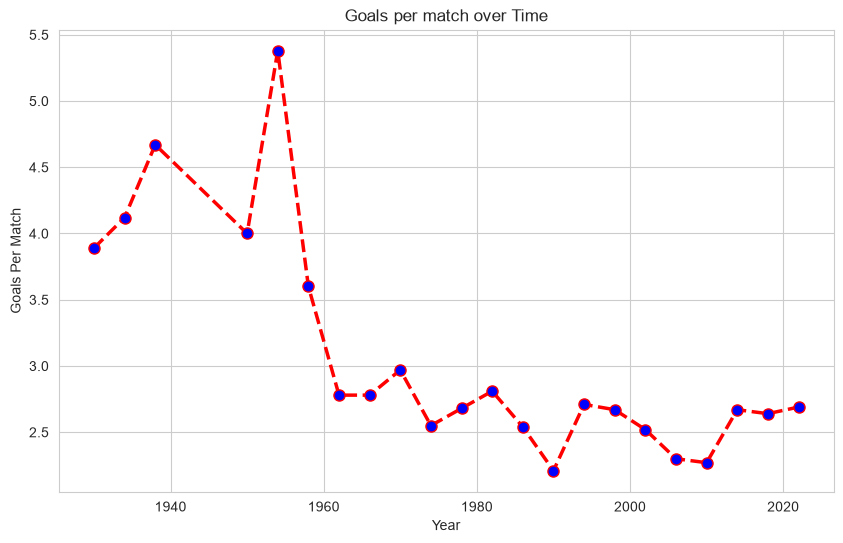

In [66]:
plt.plot(
    wc_editions['year'], wc_editions['goals_per_match'],
    color='red',
    linestyle='--',
    linewidth=2.5,
    marker='o',
    markersize=8,
    markerfacecolor='blue'
)

plt.title("Goals per match over Time")
plt.xlabel("Year")
plt.ylabel("Goals Per Match")
plt.show()

### Attendance growth over Decades

Same reasoning as the previous chart: attendance is tracked continuously across editions, so a line plot represents its growth more honestly than discrete bars would.

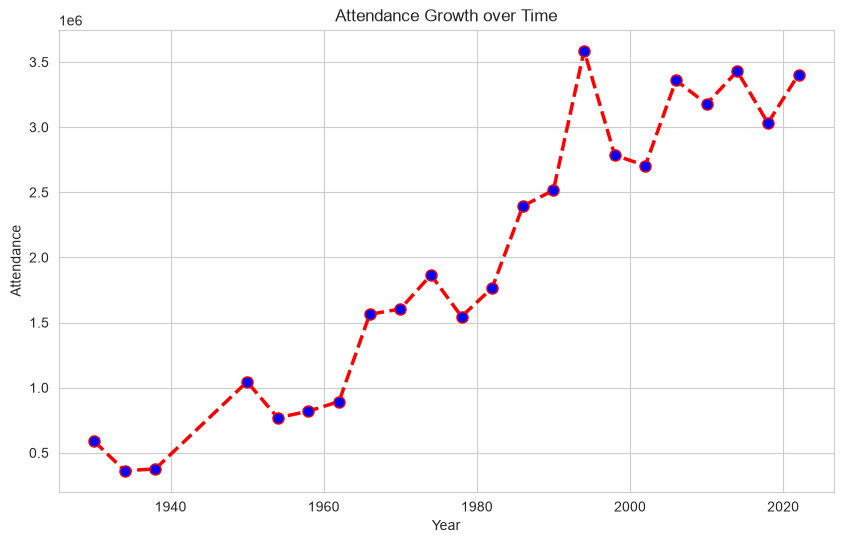

In [67]:
plt.plot(
    wc_editions['year'], wc_editions['attendance'],
    color='red',
    linestyle='--',
    linewidth=2.5,
    marker='o',
    markersize=8,
    markerfacecolor='blue'
)

plt.title("Attendance Growth over Time")
plt.xlabel("Year")
plt.ylabel("Attendance")
plt.show()

### Team Count Growth

Team count only changes when FIFA actually changes the tournament format — it doesn't move continuously between editions. A bar chart represents that better than a line, since it visually emphasizes the step-changes (24 → 32 → 48) rather than implying a smooth, gradual increase that never actually happened.

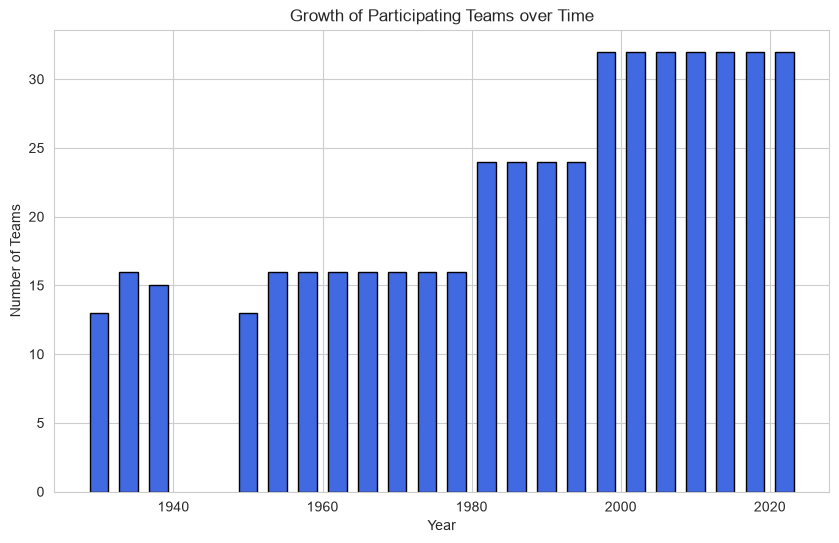

In [68]:
plt.bar(
    wc_editions["year"],
    wc_editions["teams"],
    color="royalblue",
    edgecolor="black",
    width=2.5,
)

plt.title("Growth of Participating Teams over Time")
plt.xlabel("Year")
plt.ylabel("Number of Teams")
plt.show()


### Host Advantage

Host advantage is a binary outcome (won or didn't) across a small sample of 21 tournaments — small enough that a plain count communicates the fact more directly than a chart would. The bar chart here is really just a visual restatement of the printed ratio, useful for a carousel slide rather than for uncovering anything a single sentence couldn't already say.

Hosts have won the World Cup 6 out of 22 times (27.3%)


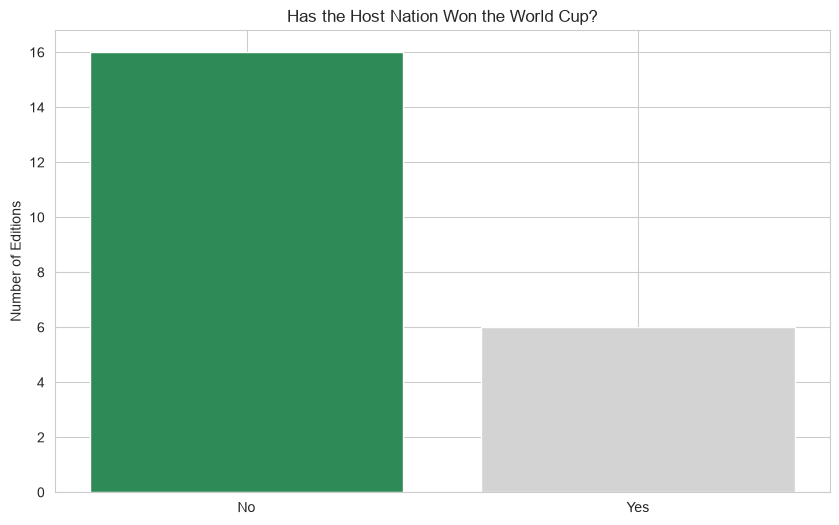

In [69]:
host_win_counts = wc_editions['host_won'].value_counts()
total = len(wc_editions)
wins = host_win_counts.get('Yes', 0)

print(f"Hosts have won the World Cup {wins} out of {total} times ({wins/total:.1%})")

plt.bar(host_win_counts.index, host_win_counts.values, color=['seagreen', 'lightgray'])
plt.title("Has the Host Nation Won the World Cup?")
plt.ylabel("Number of Editions")
plt.show()

## 5. Golden Boot Angle

Shifting focus from the tournament as a whole to individual performance — this section checks whether the top scorer's goal tally has changed over time, how it relates to overall tournament scoring, and whether scoring more goals as an individual correlates with how far that player's team advanced.

### Top Scorer Goals Over Time

One value per tournament, plotted as discrete bars rather than a connected line — each edition's top scorer is an independent event, not a continuously varying measurement, so bars avoid implying a smooth trend that isn't really there.

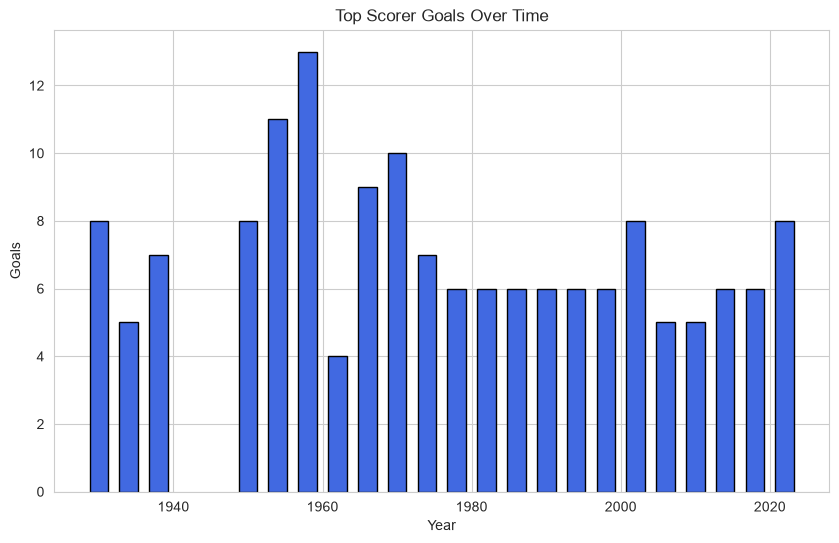

In [70]:
plt.bar(
    wc_top_scorers['year'],
    wc_top_scorers['goals'],
    color="royalblue",
    edgecolor="black",
    width=2.5,
)

plt.title("Top Scorer Goals Over Time")
plt.xlabel("Year")
plt.ylabel("Goals")
plt.show()

### Top Scorer Goals against Overall Tournament Scoring

These two metrics live on very different scales — goals-per-match is a small decimal, top scorer goals is a whole number in the low double digits — so a shared y-axis would flatten one of them into an unreadable flat line. A twin-axis plot lets both trends be read at their own natural scale, on the same time axis, so the two can still be visually compared side by side.

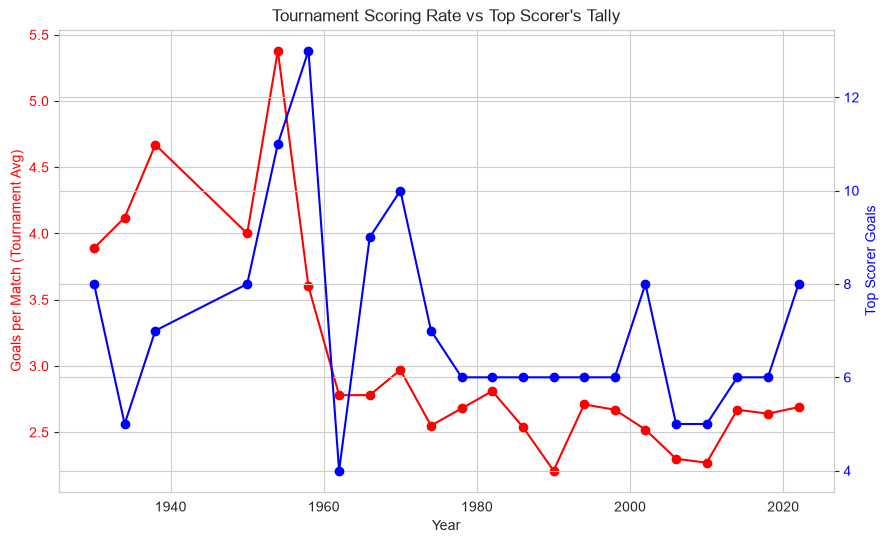

In [71]:
# Merge world cup editions and world cup top scorers on year
scoring_compare = wc_editions[['year', 'goals_per_match']].merge(
    wc_top_scorers[['year', 'goals']], on='year'
)

fig, ax1 = plt.subplots()

ax1.plot(scoring_compare['year'], scoring_compare['goals_per_match'], color='red', marker='o')
ax1.set_xlabel('Year')
ax1.set_ylabel('Goals per Match (Tournament Avg)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(scoring_compare['year'], scoring_compare['goals'], color='blue', marker='o')
ax2.set_ylabel('Top Scorer Goals', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Tournament Scoring Rate vs Top Scorer's Tally")
plt.show()

### Team result vs Goal Tally

This asks a more exploratory question: does a top scorer's personal tally relate to how far their team actually went? Grouping by `team_result` and averaging goals surfaces any pattern — though with a small dataset (21 tournaments spread across several result categories), any pattern here should be read as suggestive, not conclusive.

team_result
Runner-up        9.000000
Third place      7.555556
Champions        7.000000
Quarter-final    6.000000
Fourth place     6.000000
Semi-final       5.500000
Varies           4.000000
Name: goals, dtype: float64


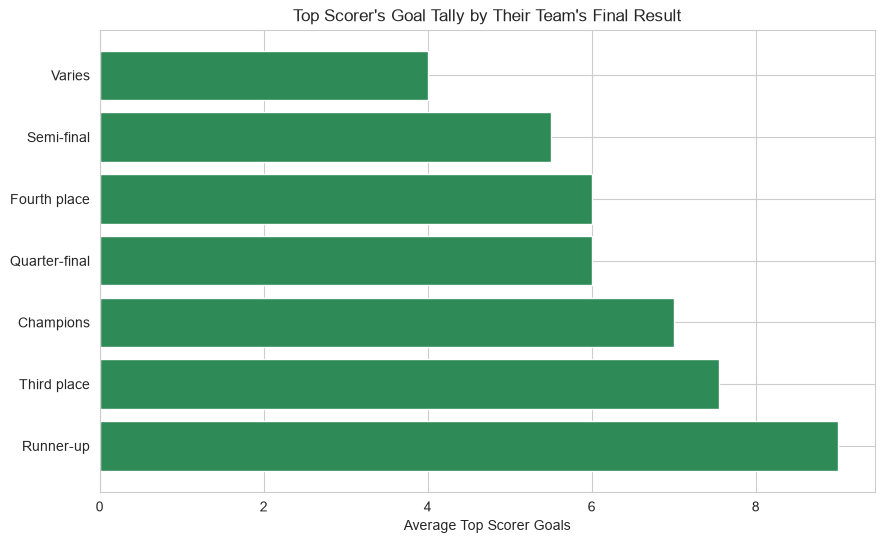

In [72]:
result_vs_goals = wc_top_scorers.groupby('team_result')['goals'].mean().sort_values(ascending=False)
print(result_vs_goals)

plt.barh(result_vs_goals.index, result_vs_goals.values, color='seagreen')
plt.xlabel('Average Top Scorer Goals')
plt.title("Top Scorer's Goal Tally by Their Team's Final Result")
plt.show()

## 6. The 48-Team Era: 2026 in Context

This section turns to the 2026 tournament itself — the first ever to feature 48 teams — and looks at what that expansion actually looks like structurally: which confederations gained representation, how competitive the resulting groups are, and how this compares to the historical format sizes covered in Section 4.

### Confederation breakdown of the 48 teams

A bar chart (rather than a pie chart) is used here deliberately — the human eye compares bar lengths far more accurately than pie slice angles, especially once there are more than two or three categories to tell apart.

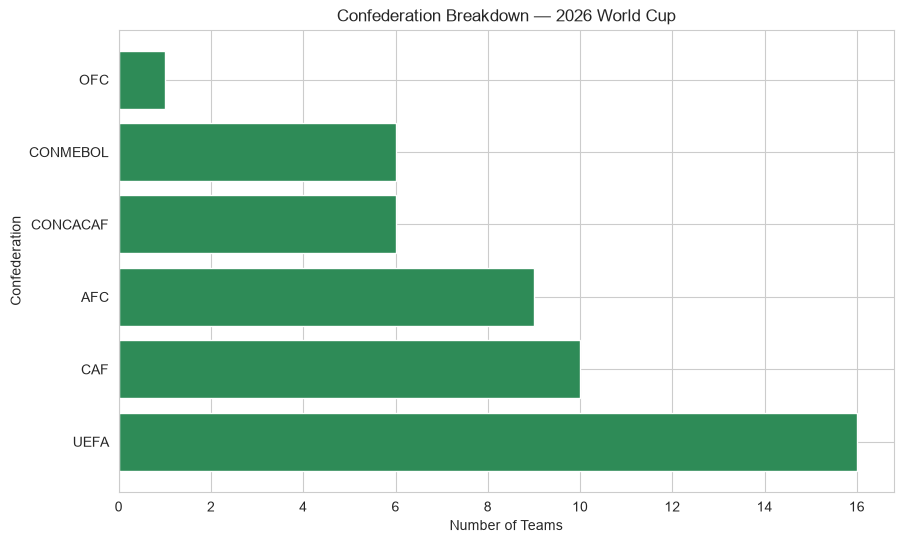

In [73]:
confederation_counts = wc26_teams['confederation'].value_counts()

plt.barh(confederation_counts.index, confederation_counts.values, color='seagreen')
plt.title("Confederation Breakdown — 2026 World Cup")
plt.xlabel("Number of Teams")
plt.ylabel("Confederation")
plt.show()

### FIFA rank distribution across groups

With only 4 teams per group, a boxplot doesn't have enough data points per category to summarize meaningfully — boxplots are built for larger samples. A stripplot instead shows every individual team's rank as its own point, which is more honest with this little data per group. The y-axis is inverted so that a higher position on the chart means a stronger team (lower FIFA rank number), matching visual intuition rather than fighting it.

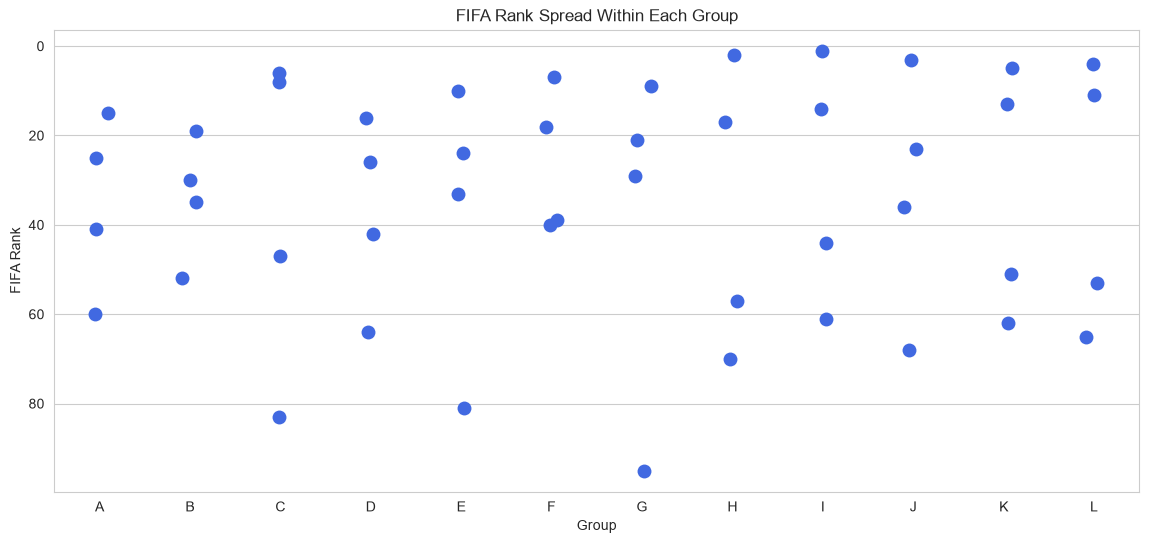

In [74]:
plt.figure(figsize=(14, 6))
sns.stripplot(data=wc26_teams, x='group', y='fifa_rank', size=10, color='royalblue')
plt.title("FIFA Rank Spread Within Each Group")
plt.xlabel("Group")
plt.ylabel("FIFA Rank")
plt.gca().invert_yaxis()
plt.show()

This context is deliberately kept as a printed statement rather than merged into `wc_editions` — that historical dataset's columns (like `goals_per_match` and `host_won`) don't have values for 2026 yet since the tournament isn't finished, and forcing a partial row in would introduce premature missing data into an otherwise complete historical table.

In [75]:
print(f"2026 marks the tournament's biggest expansion yet: {wc26_teams.shape[0]} teams, "
      f"up from {wc_editions['teams'].iloc[-1]} in 2022 — a jump of "
      f"{wc26_teams.shape[0] - wc_editions['teams'].iloc[-1]} teams.")

2026 marks the tournament's biggest expansion yet: 48 teams, up from 32 in 2022 — a jump of 16 teams.


## 7. Group Stage Deep Dive

Zooming into the group stage specifically — this section quantifies competitiveness (how mismatched are the teams within each group) and looks at which confederations are gaining first-time representation in the expanded format.

### 7a. Average FIFA rank gap within each group

The FIFA rank spread visualized in Section 6 gets turned into an actual number here — the gap between each group's highest and lowest ranked team. A small gap means an evenly matched, and potentially harder to predict, group; a large gap suggests one dominant team and one clear underdog.

In [76]:
rank_gaps = wc26_teams.groupby("group")['fifa_rank'].agg(['min', 'max'])
rank_gaps['gap'] = rank_gaps['max'] - rank_gaps['min']
rank_gaps.sort_values('gap').head()

,min,max,gap
group,,,
B,19,52,33
F,7,40,33
A,15,60,45
D,16,64,48
K,5,62,57


Filtering to just the teams making their first-ever World Cup appearance, then breaking that down by confederation, shows where the 48-team expansion is actually creating new opportunities — rather than just diluting existing confederations' allocations.

### 7b. Debut Teams

In [77]:
debut_teams = wc26_teams[wc26_teams["debut_2026"] == "Yes"]
print(f"{len(debut_teams)} teams are making their World Cup debut in 2026")
debut_teams['confederation'].value_counts()

4 teams are making their World Cup debut in 2026


confederation
AFC         2
CONCACAF    1
CAF         1
Name: count, dtype: int64

## 8. Results So Far (placeholder — updated as the tournament progresses)

Since the 2026 tournament was still underway at the time this notebook was built, this section exists as a living log rather than a one-time analysis — updated with each new completed round, so the notebook stays a running companion to the tournament rather than a snapshot frozen at kickoff.

Each round's results are entered as a list of match dictionaries, then converted into a DataFrame — matching the same shape as the historical `wc_matches` data so it stays directly comparable. An `*Added: [date]*` line accompanies each round's header, giving a visible timestamp trail for when each chunk of analysis was added.

### 8a. Round of 32 Results
*Added: July 6, 2026*

In [78]:
wc_2026_results = [
    {
        "stage": "Round of 32",
        "date": "2026-06-28",
        "team1": "South Africa",
        "team2": "Canada",
        "score1": 0,
        "score2": 1,
        "winner": "Canada",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 32",
        "date": "2026-06-29",
        "team1": "Brazil",
        "team2": "Japan",
        "score1": 2,
        "score2": 1,
        "winner": "Brazil",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 32",
        "date": "2026-06-29",
        "team1": "Germany",
        "team2": "Paraguay",
        "score1": 1,
        "score2": 1,
        "winner": "Paraguay",
        "decided_by": "Penalties",
        "penalty_score": "3-4"
    },
    {
        "stage": "Round of 32",
        "date": "2026-06-29",
        "team1": "Netherlands",
        "team2": "Morocco",
        "score1": 1,
        "score2": 1,
        "winner": "Morocco",
        "decided_by": "Penalties",
        "penalty_score": "2-3"
    },
    {
        "stage": "Round of 32",
        "date": "2026-06-30",
        "team1": "Ivory Coast",
        "team2": "Norway",
        "score1": 1,
        "score2": 2,
        "winner": "Norway",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 32",
        "date": "2026-06-30",
        "team1": "France",
        "team2": "Sweden",
        "score1": 3,
        "score2": 0,
        "winner": "France",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 32",
        "date": "2026-06-30",
        "team1": "Mexico",
        "team2": "Ecuador",
        "score1": 2,
        "score2": 0,
        "winner": "Mexico",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 32",
        "date": "2026-07-01",
        "team1": "England",
        "team2": "DR Congo",
        "score1": 2,
        "score2": 1,
        "winner": "England",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 32",
        "date": "2026-07-01",
        "team1": "Belgium",
        "team2": "Senegal",
        "score1": 3,
        "score2": 2,
        "winner": "Belgium",
        "decided_by": "Extra Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 32",
        "date": "2026-07-01",
        "team1": "USA",
        "team2": "Bosnia & Herzegovina",
        "score1": 2,
        "score2": 0,
        "winner": "USA",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 32",
        "date": "2026-07-02",
        "team1": "Spain",
        "team2": "Austria",
        "score1": 3,
        "score2": 0,
        "winner": "Spain",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 32",
        "date": "2026-07-02",
        "team1": "Portugal",
        "team2": "Croatia",
        "score1": 2,
        "score2": 1,
        "winner": "Portugal",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 32",
        "date": "2026-07-02",
        "team1": "Switzerland",
        "team2": "Algeria",
        "score1": 2,
        "score2": 0,
        "winner": "Switzerland",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 32",
        "date": "2026-07-03",
        "team1": "Australia",
        "team2": "Egypt",
        "score1": 1,
        "score2": 1,
        "winner": "Egypt",
        "decided_by": "Penalties",
        "penalty_score": "2-4"
    },
    {
        "stage": "Round of 32",
        "date": "2026-07-03",
        "team1": "Argentina",
        "team2": "Cape Verde",
        "score1": 3,
        "score2": 2,
        "winner": "Argentina",
        "decided_by": "Extra Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 32",
        "date": "2026-07-03",
        "team1": "Colombia",
        "team2": "Ghana",
        "score1": 1,
        "score2": 0,
        "winner": "Colombia",
        "decided_by": "Normal Time",
        "penalty_score": None
    }
]


wc_2026_results_df = pd.DataFrame(wc_2026_results)
print(wc_2026_results_df.shape)
wc_2026_results_df.head()

(16, 9)


,stage,date,team1,team2,score1,score2,winner,decided_by,penalty_score
0,Round of 32,2026-06-28,South Africa,Canada,0,1,Canada,Normal Time,NaN
1,Round of 32,2026-06-29,Brazil,Japan,2,1,Brazil,Normal Time,NaN
2,Round of 32,2026-06-29,Germany,Paraguay,1,1,Paraguay,Penalties,3-4
3,Round of 32,2026-06-29,Netherlands,Morocco,1,1,Morocco,Penalties,2-3
4,Round of 32,2026-06-30,Ivory Coast,Norway,1,2,Norway,Normal Time,NaN


- **Germany was eliminated by Paraguay on penalties** — one of the tournament's biggest shocks so far, given Germany entered as a favorite.
- **One standout comeback:** Belgium erased a 2-0 deficit against Senegal in the final minutes to advance 3-2 in extra time — a reminder that group-stage form doesn't always predict knockout resilience.
- **Most African confederation teams were eliminated in the Round of 32**, with Morocco and Egypt the exceptions advancing to the Round of 16.

### 8b. Round of 16 Results
*Added: July 8, 2026*

In [79]:
wc_2026_results_r16 = [
    {
        "stage": "Round of 16",
        "date": "2026-07-04",
        "team1": "Canada",
        "team2": "Morocco",
        "score1": 0,
        "score2": 3,
        "winner": "Morocco",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 16",
        "date": "2026-07-04",
        "team1": "Paraguay",
        "team2": "France",
        "score1": 0,
        "score2": 1,
        "winner": "France",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 16",
        "date": "2026-07-05",
        "team1": "Brazil",
        "team2": "Norway",
        "score1": 1,
        "score2": 2,
        "winner": "Norway",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 16",
        "date": "2026-07-05",
        "team1": "Mexico",
        "team2": "England",
        "score1": 2,
        "score2": 3,
        "winner": "England",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 16",
        "date": "2026-07-06",
        "team1": "Portugal",
        "team2": "Spain",
        "score1": 0,
        "score2": 1,
        "winner": "Spain",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 16",
        "date": "2026-07-06",
        "team1": "United States",
        "team2": "Belgium",
        "score1": 1,
        "score2": 4,
        "winner": "Belgium",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 16",
        "date": "2026-07-07",
        "team1": "Argentina",
        "team2": "Egypt",
        "score1": 3,
        "score2": 2,
        "winner": "Argentina",
        "decided_by": "Normal Time",
        "penalty_score": None
    },
    {
        "stage": "Round of 16",
        "date": "2026-07-07",
        "team1": "Switzerland",
        "team2": "Colombia",
        "score1": 0,
        "score2": 0,
        "winner": "Switzerland",
        "decided_by": "Penalties",
        "penalty_score": "4-3"
    }
]


wc_2026_results_df = pd.concat(
    [wc_2026_results_df, pd.DataFrame(wc_2026_results_r16)],
    ignore_index=True
)
print(wc_2026_results_df.shape)
wc_2026_results_df.tail()

(24, 9)


,stage,date,team1,team2,score1,score2,winner,decided_by,penalty_score
19,Round of 16,2026-07-05,Mexico,England,2,3,England,Normal Time,NaN
20,Round of 16,2026-07-06,Portugal,Spain,0,1,Spain,Normal Time,NaN
21,Round of 16,2026-07-06,United States,Belgium,1,4,Belgium,Normal Time,NaN
22,Round of 16,2026-07-07,Argentina,Egypt,3,2,Argentina,Normal Time,NaN
23,Round of 16,2026-07-07,Switzerland,Colombia,0,0,Switzerland,Penalties,4-3


- **Brazil eliminated in the Round of 16** — losing 1-2 to Norway, one of the round's more unexpected results given Brazil's historical pedigree in the earlier sections' data.
- **Two of the widest scorelines so far:** Belgium's 4-1 win over the USA and Morocco's 3-0 win over Canada — both decisive margins compared to the mostly tight, single-goal results seen elsewhere in the round.
- **Morocco continues its run** — having already eliminated Netherlands on penalties in Round of 32, they followed it up with a comfortable Round of 16 win, making them one of the round's more consistent performers so far.
- **A second penalty shootout of the knockout stage:** Switzerland needed penalties (4-3) to get past Colombia, after Round of 32 also saw two shootouts (Paraguay, Egypt) — worth flagging as an observation, not yet a "trend," since it's still early days across two rounds.

### 8c. Quarter Final Results
*Added: {Date}*

In [80]:
# wc_2026_results_qtr = [
#     # ... Quarter Final Results
# ]

# wc_2026_results_df = pd.concat(
#     [wc_2026_results_df, pd.DataFrame(wc_2026_results_r16)],
#     ignore_index=True
# )
# print(wc_2026_results_df.shape)

This block stays commented out until the Quarter Final concludes — at which point it follows the exact same pattern as 8a: a fresh list of match dictionaries, appended onto the existing results table with `pd.concat` rather than rebuilding it from scratch, so earlier rounds are never re-typed or disturbed.

## 9. Wrap-up / Key Takeaways

### Pre-Tournament Takeaways

- **Attendance has grown considerably over time**, peaking in 1994 (USA) — reflecting the tournament's steady expansion in both scale and global reach.
- **Home advantage doesn't guarantee a win.** Only 6 out of 21 host nations have gone on to win the tournament they hosted — a smaller edge than "home advantage" might suggest.
- **Scoring has cooled since the WWII-era tournaments.** Both goals-per-match and top-scorer tallies trend downward in the modern era compared to early editions — visible in both the historical scoring chart and the tournament-rate-vs-top-scorer comparison.

### In-Progress Takeaways — Round of 32

- **5 of 16 matches (31%) went beyond 90 minutes** — 3 decided on penalties (Germany vs Paraguay, Netherlands vs Morocco, Australia vs Egypt) and 2 in extra time (Belgium vs Senegal, Argentina vs Cape Verde) — a notably high rate of drama for an opening knockout round.
- **Germany's exit stands out as the round's biggest shock**, losing to Paraguay on penalties despite entering as a tournament favorite.
- **African representation was cut in half** — 6 of 8 African confederation teams (South Africa, Ivory Coast, DR Congo, Senegal, Algeria, Ghana) were eliminated, leaving only Morocco and Egypt to advance.
- **Belgium's comeback against Senegal** was the round's standout reversal — erasing a 2-0 deficit late in the second half before winning in extra time.

### In-Progress Takeaways — Round of 16

- **Brazil was eliminated**, losing 1-2 to Norway — one of the round's more unexpected results.
- **Morocco continued its run**, following up their Round of 32 penalty win over Netherlands with a comfortable 3-0 win over Canada.
- **A second knockout-stage penalty shootout** — Switzerland edged past Colombia 4-3 on penalties after a scoreless 90 minutes.
- **Widest margins of the round**: Belgium 4-1 over USA and Morocco 3-0 over Canada, standing out against an otherwise tight set of results.
